### Procedimiento de cargue de las librerías

In [90]:
import pandas as pd
import numpy as np
import sklearn as sk

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

import scipy.stats as stats
from scipy.stats import normaltest


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.model_selection import cross_validate

### Procedimiento de cargue de la data cruda

In [92]:
ruta = r"C:\Users\mauri\Downloads/raw_data_customers.csv"

with open(ruta, "r", encoding="utf-8") as f:
    lines = [line.strip().strip('"') for line in f]


In [93]:
rows = [line.split(",") for line in lines]

data = pd.DataFrame(rows[1:], columns=rows[0])


In [94]:
data.info()# A partir de la salida generada se procederá a realizar el tratamiento de la fuente de datos.
# la fuente dispone de 10 columnas y 114 registros.

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   customer_id         114 non-null    str  
 1   full_name           114 non-null    str  
 2   email               114 non-null    str  
 3   phone               114 non-null    str  
 4   signup_date         114 non-null    str  
 5   last_purchase_date  114 non-null    str  
 6   monthly_spend       114 non-null    str  
 7   total_shipments     114 non-null    str  
 8   churn_label         114 non-null    str  
 9   home_address        114 non-null    str  
dtypes: str(10)
memory usage: 18.4 KB


### Procesamiento de datos

#### Cargue inicial de datos

In [97]:
data = data.sort_values("customer_id", ascending=True).reset_index(drop=True)
data.head(10)# se identificaron registros duplicados como por ejemplo  customer_id=C001, el cual tiene las demás variables por igual.
#Las fechas tienen diferentes formas de escritura por ejemplo YYYY-MM-DD, DD/MM/YYYY

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.50,12,0,Calle Falsa 123
1,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.50,12,0,Calle Falsa 123
2,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-05-10,1200.00,45,0,Carrera 7 # 45-10
3,C003,Carlos Rodriguez,c.rod@work.com,,2023-03-05,03/25/2025,NULL,8,1,Av. Siempre Viva 742
4,C003,Carlos Rodriguez,c.rod@work.com,,2023-03-05,03/25/2025,99999,8,1,Av. Siempre Viva 742
5,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-04-12,2025-06-01,890.20,22,0,Clle 100 # 15
6,C005,Luis Herrera,lherrera@domain.org,555-0105,2023-05-30,2024-12-20,310.00,5,1,Apt 502 Torre B
7,C006,Sonia Castro,scastro@test.com,555-0106,21/06/2023,2025-04-15,2500.00,,0,Calle 80 # 20
8,C007,Roberto Gomez,rgomez@mail.com,555-0107,2023-07-02,NULL,150.00,2,1,Diagonal 45
9,C008,Elena Blanco,e.blanco@service.com,555-0108,2023-08-14,2025-05-28,-50.00,15,0,Transversal 12


### Preparación de datos

#### Arreglo de los registros con nulos o vacios:
- Se realizó proceso de convertir registros NULL o N/A a formato nan de numpy.

In [100]:
data["phone"] =data["phone"].replace(["NULL", "N/A", ""], np.nan)
data["signup_date"] =data["signup_date"].replace(["NULL", "N/A", ""], np.nan)
data["last_purchase_date"] = data["last_purchase_date"].replace(["NULL", "N/A", ""], np.nan)
data["monthly_spend"] = data["monthly_spend"].replace(["NULL", "N/A", ""], np.nan)
data["total_shipments"] = data["total_shipments"].replace(["NULL", "N/A", ""], np.nan)
data["home_address"] = data["home_address"].replace(["NULL", "N/A", ""], np.nan)

data['churn_label'] = pd.to_numeric(data['churn_label'], errors='coerce')
data.head(10)

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.50,12,0.0,Calle Falsa 123
1,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.50,12,0.0,Calle Falsa 123
2,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-05-10,1200.00,45,0.0,Carrera 7 # 45-10
3,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,03/25/2025,NaN,8,1.0,Av. Siempre Viva 742
4,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,03/25/2025,99999,8,1.0,Av. Siempre Viva 742
5,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-04-12,2025-06-01,890.20,22,0.0,Clle 100 # 15
6,C005,Luis Herrera,lherrera@domain.org,555-0105,2023-05-30,2024-12-20,310.00,5,1.0,Apt 502 Torre B
7,C006,Sonia Castro,scastro@test.com,555-0106,21/06/2023,2025-04-15,2500.00,NaN,0.0,Calle 80 # 20
8,C007,Roberto Gomez,rgomez@mail.com,555-0107,2023-07-02,NaN,150.00,2,1.0,Diagonal 45
9,C008,Elena Blanco,e.blanco@service.com,555-0108,2023-08-14,2025-05-28,-50.00,15,0.0,Transversal 12


#### Tratamiento para las variables de fecha
Se evidencia diferentes tipos de formatos de fecha, de esta manera se dejará el formato YYYY-MM-DD.

In [102]:
data['last_purchase_date'] = pd.to_datetime(
    data['last_purchase_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [103]:
data['signup_date'] = pd.to_datetime(
    data['signup_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [104]:
data.head(10)

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,2025-05-12,450.50,12,0.0,Calle Falsa 123
1,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,2025-05-12,450.50,12,0.0,Calle Falsa 123
2,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-10-05,1200.00,45,0.0,Carrera 7 # 45-10
3,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-05-03,2025-03-25,NaN,8,1.0,Av. Siempre Viva 742
4,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-05-03,2025-03-25,99999,8,1.0,Av. Siempre Viva 742
5,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-12-04,2025-01-06,890.20,22,0.0,Clle 100 # 15
6,C005,Luis Herrera,lherrera@domain.org,555-0105,2023-05-30,2024-12-20,310.00,5,1.0,Apt 502 Torre B
7,C006,Sonia Castro,scastro@test.com,555-0106,2023-06-21,2025-04-15,2500.00,NaN,0.0,Calle 80 # 20
8,C007,Roberto Gomez,rgomez@mail.com,555-0107,2023-02-07,NaT,150.00,2,1.0,Diagonal 45
9,C008,Elena Blanco,e.blanco@service.com,555-0108,2023-08-14,2025-05-28,-50.00,15,0.0,Transversal 12


#### Tratamiento para los registros duplicados
Se evidencia registros duplicados a partir de la variable customer_id. Por lo tanto se procede a dejar el primer registro.

In [106]:
#Quitar duplicados y dejar el más reciente
data = data.sort_values(by=['customer_id', 'last_purchase_date'], ascending=[True, False])
data = data.drop_duplicates(subset=['customer_id'], keep='first')

#### Tratamiento para las variables monthly_spend y total_shipments a formato numérico
- Se evidencia registros con valores de 99999 el cual reportaría como casilla vacia y se dejaría como 0.
- Se evidencia reporte de registros negativos, se supone que debe ser problemas de la base, por tanto se deja en valor absoluto.

In [108]:
#data['monthly_spend'] = data['monthly_spend'].replace(99999, pd.NA)
data['monthly_spend'] = data['monthly_spend'].fillna(0).astype(float)
data['monthly_spend'] = data['monthly_spend'].replace(99999.00, 0)
data['monthly_spend'] = data['monthly_spend'].abs()


#data['total_shipments'] = data['total_shipments'].replace(99999, pd.NA)
data['total_shipments'] = data['total_shipments'].fillna(0).astype(float)
data['total_shipments'] = data['total_shipments'].replace(99999.00, 0)
data['total_shipments'] = data['total_shipments'].abs()

In [109]:
data.head(10)

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,2025-05-12,450.50,12.0,0.0,Calle Falsa 123
2,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-10-05,1200.00,45.0,0.0,Carrera 7 # 45-10
3,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-05-03,2025-03-25,0.00,8.0,1.0,Av. Siempre Viva 742
5,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-12-04,2025-01-06,890.20,22.0,0.0,Clle 100 # 15
6,C005,Luis Herrera,lherrera@domain.org,555-0105,2023-05-30,2024-12-20,310.00,5.0,1.0,Apt 502 Torre B
7,C006,Sonia Castro,scastro@test.com,555-0106,2023-06-21,2025-04-15,2500.00,0.0,0.0,Calle 80 # 20
8,C007,Roberto Gomez,rgomez@mail.com,555-0107,2023-02-07,NaT,150.00,2.0,1.0,Diagonal 45
9,C008,Elena Blanco,e.blanco@service.com,555-0108,2023-08-14,2025-05-28,50.00,15.0,0.0,Transversal 12
10,C009,Pedro Infante,p.infante@mail.co,555-0109,2023-01-09,2025-10-01,600.75,10.0,0.0,Calle 10 # 5-40
11,C010,Martha Lucía,mlucia@xyz.com,555-0110,2023-10-10,2024-10-10,420.00,1000.0,NaN,NaN


#### Creación variables
- Se crea la variable "tiempo_suscripcion_meses", que es la diferencia entre "last_purchase_date" y "signup_date"
- Se crea la variable "gasto_de_envio_por_mes", que es la relación entre "monthly_spend" y "total_shipments"

In [111]:
data['tiempo_suscripcion_meses'] = ((data['last_purchase_date'] - data['signup_date']).dt.days / 30).round(2).round(2).fillna(0).abs()

data['gasto_de_envio_por_mes'] = data['monthly_spend'] / (data['total_shipments'] + 1)  #gasto mensual entre el número de envíos

In [112]:
data.info() # se puede evidenciar el proceso de transformación de los datos paulatinamente 
#y creación de nuevas variables de negocio.

<class 'pandas.DataFrame'>
Index: 110 entries, 0 to 113
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               110 non-null    str           
 1   full_name                 110 non-null    str           
 2   email                     110 non-null    str           
 3   phone                     109 non-null    str           
 4   signup_date               110 non-null    datetime64[us]
 5   last_purchase_date        109 non-null    datetime64[us]
 6   monthly_spend             110 non-null    float64       
 7   total_shipments           110 non-null    float64       
 8   churn_label               109 non-null    float64       
 9   home_address              102 non-null    str           
 10  tiempo_suscripcion_meses  110 non-null    float64       
 11  gasto_de_envio_por_mes    110 non-null    float64       
dtypes: datetime64[us](2), float64(5), str(

#### Análisis exploratorio de datos
-Se genera una tabla de las variables numéricas con el fin de conocer sus medidas de tendencia central, conteo, máximo y mínimo.
- De manera general la variable "tiempo_suscripcion_meses" no presenta tanta dipersión al comparar la desviación estándar y la media.
- Las demás variables preesentan dispersión alta.

In [114]:
u=data[['monthly_spend', 'total_shipments','tiempo_suscripcion_meses','gasto_de_envio_por_mes']].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
])

display(u)

,monthly_spend,total_shipments,tiempo_suscripcion_meses,gasto_de_envio_por_mes
count,110.000000,110.000000,110.000000,110.000000
mean,1329.013182,59.090909,13.386727,49.191387
median,600.000000,22.000000,12.300000,27.046277
std,2071.477983,120.193540,8.502979,237.683049
min,0.000000,0.000000,0.000000,0.000000
max,10000.000000,1000.000000,35.500000,2500.000000


- La variable objetivo "churn_label" se le realiza un proceso de imputación por moda.

In [116]:
moda_valor = data['churn_label'].mode()[0]
data['churn_label'] = data['churn_label'].fillna(moda_valor)

data['churn_label'].value_counts()

churn_label
0.0    83
1.0    27
Name: count, dtype: int64

##### Pruebas de normalidad
- se realiza histograma para evidenciar la distribución de las variables numéricas para corroborar la no distribución normal
- Se realiza la prueba gráfica con el método Q-Q plot de las variables numéricas.
- Se realiza la prueba de normalidad de D’Agostino y Pearson, la cual viene por defecto en el paquete, y permite combinar asimetría y curtosis.

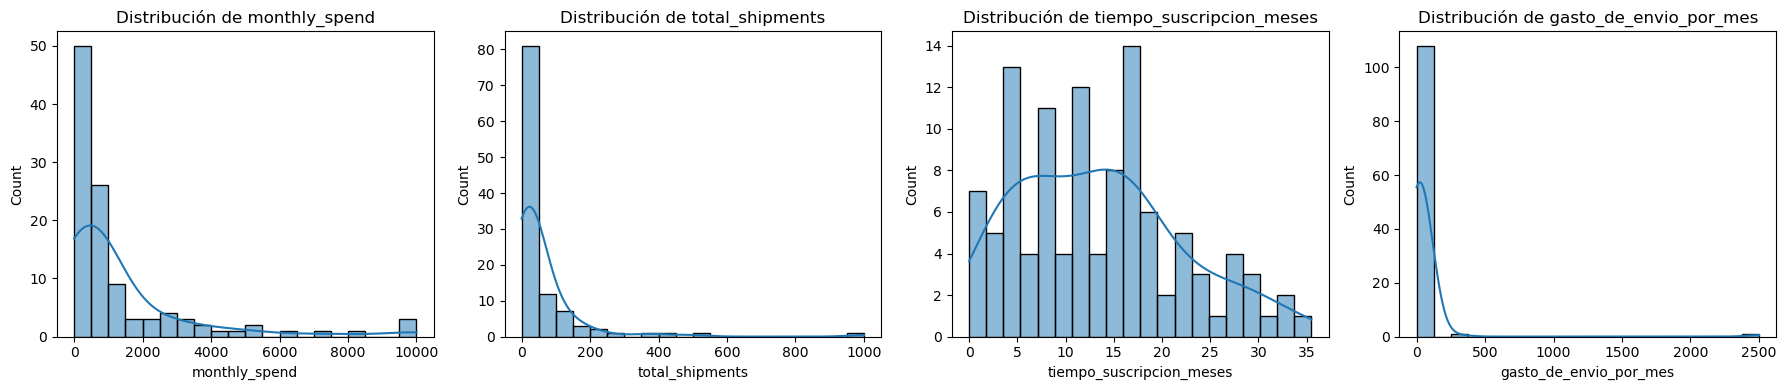

In [118]:
cols = ['monthly_spend', 'total_shipments', 'tiempo_suscripcion_meses','gasto_de_envio_por_mes']

plt.figure(figsize=(18, 4))

for i, col in enumerate(cols):
    plt.subplot(1, 4, i+1)
    sns.histplot(data[col], bins=20, kde=True)
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

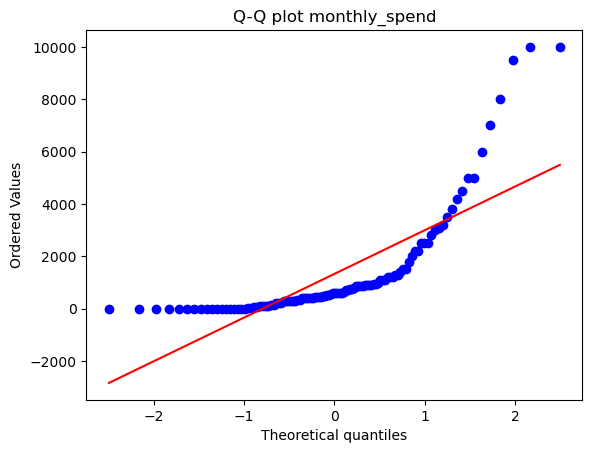

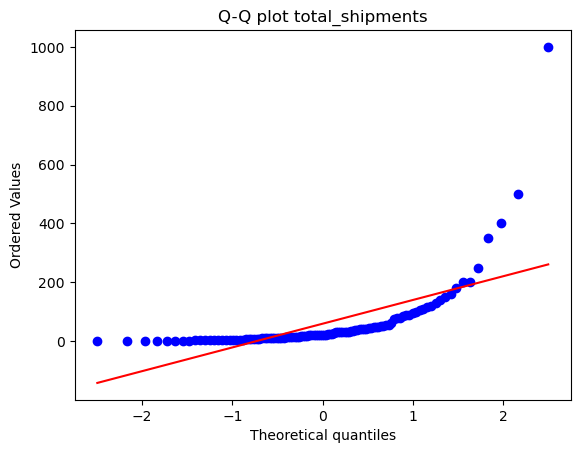

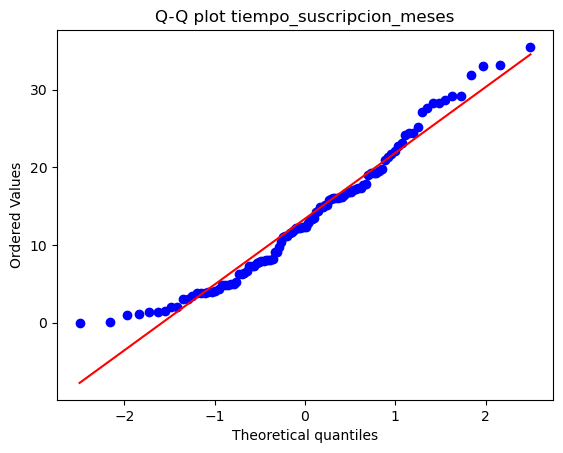

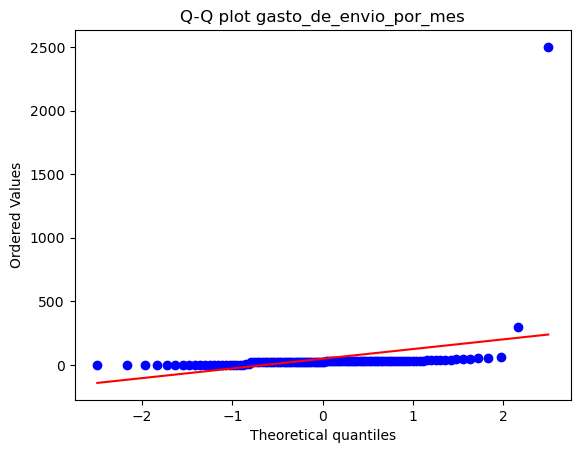

In [119]:
cols = ['monthly_spend','total_shipments','tiempo_suscripcion_meses','gasto_de_envio_por_mes'
]
for col in cols:
    plt.figure()
    stats.probplot(data[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q plot {col}")
    plt.show()

In [120]:
for col in cols:
    stat, p = normaltest(data[col].dropna())
    print(f"{col}: estadístico={stat:.4f}, p-value={p:.4f}")

monthly_spend: estadístico=79.2919, p-value=0.0000
total_shipments: estadístico=156.4285, p-value=0.0000
tiempo_suscripcion_meses: estadístico=5.7154, p-value=0.0574
gasto_de_envio_por_mes: estadístico=234.7819, p-value=0.0000


- Con un nivel de significancia del 5% (0.05) se evidencia que ninguna de las variables de tipo numérico cumple con supuestos normalidad.
- Posteriormente se realizarán técnicas de transformación al mometo de realizar la modelación.

##### Pruebas de correlación Spearman
- Se realiza la prueba de correlación de Spearman entre las variables numéricas ya que no existe normalidad entre ellas.
- Los resultados arrojan correlación fuerte entre "total_shipments" y "monthly_spend", lo que indica una relación directamente proporcional. Es decir a medida que aumenta "total_shipments" también aumenta "monthly_spend". Los demás pares de variables presentan correlación débil.

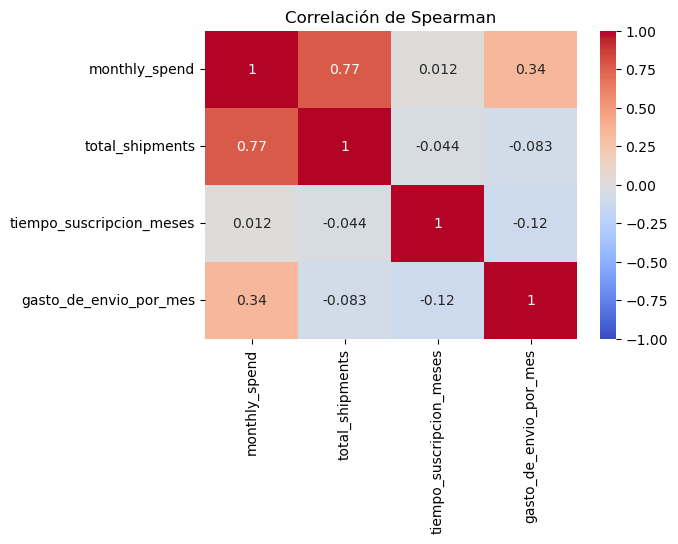

In [123]:
variables = [
    'monthly_spend',
    'total_shipments',
    'tiempo_suscripcion_meses',
    'gasto_de_envio_por_mes'
]

# Matriz de correlación de Spearman
corr_spearman = data[variables].corr(method='spearman')

plt.figure(figsize=(6,4))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlación de Spearman")
plt.show()

##### Diagramas de Box-plot
- Se toma la variable objetivo "Churn" vs las demás variables numéricas para detallar comportamientos.
- La relación entre "monthly_spend" y "Churn" , "total_shipments" y "Churn" son diferenciadoras ya que permite identificar valores muy bajos de la mediana se identifican las personas con "Churn"=1 (desertores). Es decir personas que gastan menos mensualmente o personas que envían poco son las más propensas a desertar.
- "tiempo_suscripcion_meses" y churn no presentan diferenncias significativas.
- 

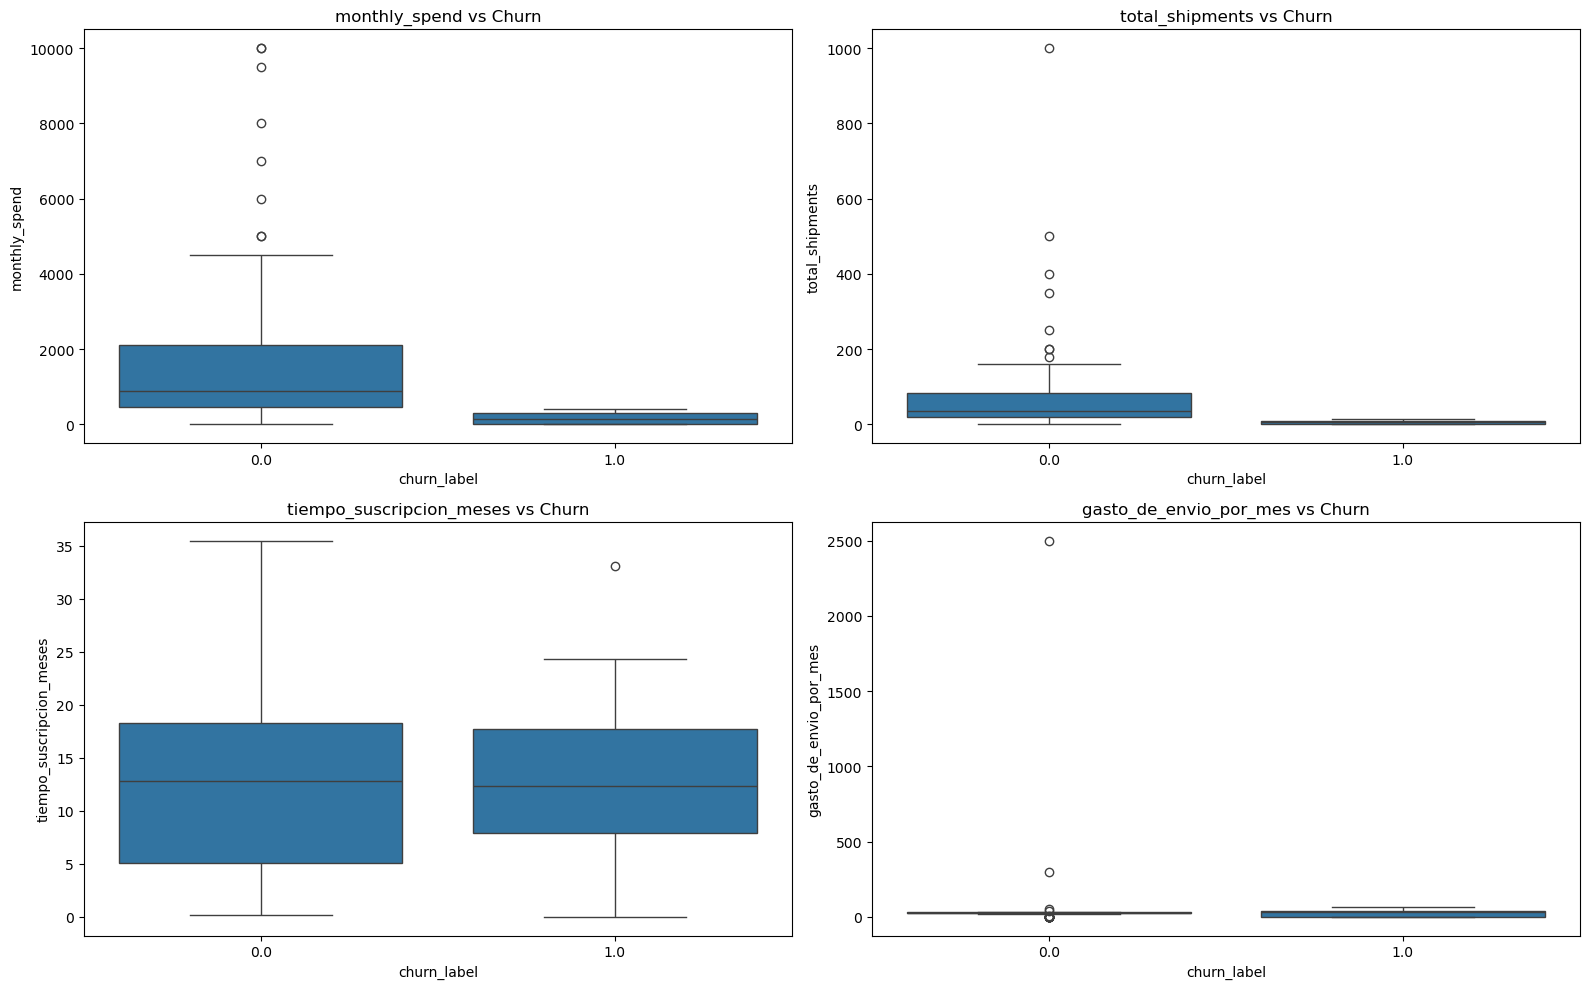

In [125]:
cols = [
    'monthly_spend',
    'total_shipments',
    'tiempo_suscripcion_meses',
    'gasto_de_envio_por_mes'
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='churn_label', y=col, data=data)
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

In [126]:
data.head(10)# fuente depurada y analizada

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address,tiempo_suscripcion_meses,gasto_de_envio_por_mes
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,2025-05-12,450.50,12.0,0.0,Calle Falsa 123,28.27,34.653846
2,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-10-05,1200.00,45.0,0.0,Carrera 7 # 45-10,31.93,26.086957
3,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-05-03,2025-03-25,0.00,8.0,1.0,Av. Siempre Viva 742,23.07,0.000000
5,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-12-04,2025-01-06,890.20,22.0,0.0,Clle 100 # 15,13.30,38.704348
6,C005,Luis Herrera,lherrera@domain.org,555-0105,2023-05-30,2024-12-20,310.00,5.0,1.0,Apt 502 Torre B,19.00,51.666667
7,C006,Sonia Castro,scastro@test.com,555-0106,2023-06-21,2025-04-15,2500.00,0.0,0.0,Calle 80 # 20,22.13,2500.000000
8,C007,Roberto Gomez,rgomez@mail.com,555-0107,2023-02-07,NaT,150.00,2.0,1.0,Diagonal 45,0.00,50.000000
9,C008,Elena Blanco,e.blanco@service.com,555-0108,2023-08-14,2025-05-28,50.00,15.0,0.0,Transversal 12,21.77,3.125000
10,C009,Pedro Infante,p.infante@mail.co,555-0109,2023-01-09,2025-10-01,600.75,10.0,0.0,Calle 10 # 5-40,33.20,54.613636
11,C010,Martha Lucía,mlucia@xyz.com,555-0110,2023-10-10,2024-10-10,420.00,1000.0,0.0,NaN,12.20,0.419580


#### Modelado
- Se proponen 3 tipos de modelos para comparar el que tenga mejor calidad al momento de calcular las probabilidades de deserción de un cliente.

    - Modelo1: GradientBoostingClassifier
    - Modelo2: RandomForestClassifier
    - Modelo3: LogisticRegression

- la relación de no churn es de 83 (75.45%), mientras que churn es de 27 (24.54%). En este caso se analiza un caso desbalanceado. Se tomará cross validation estratificado

In [128]:
### MODELADO

#Preparación de la fuente
df_churn = data[['monthly_spend','total_shipments','tiempo_suscripcion_meses','gasto_de_envio_por_mes','churn_label']].copy()
df_churn['churn_label'] = df_churn['churn_label'].astype(int)


X = df_churn.drop('churn_label', axis=1)
y = df_churn['churn_label']


print(X.shape)

(110, 4)


In [129]:
print(y.value_counts())

churn_label
0    83
1    27
Name: count, dtype: int64


In [130]:
print(y.shape)

(110,)


- Se crea la muestra entrenamiento (train) y validación (test)
- Se usa StandardScaler para realizar la estandarización de las variables de tipo continuo.

In [132]:
# TRAIN Y TEST - creación de las muestras

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=123,stratify=y)

# Estandarizar variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Modelo 1 GradientBoostingClassifier

In [134]:
model1 = GradientBoostingClassifier(random_state=132)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
y_pred_cv = cross_val_predict(model1, X, y, cv=skf)
print("GRADIENT BOOSTING CLASSIFIER")
print(classification_report(y, y_pred_cv))

GRADIENT BOOSTING CLASSIFIER
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        83
           1       0.74      0.74      0.74        27

    accuracy                           0.87       110
   macro avg       0.83      0.83      0.83       110
weighted avg       0.87      0.87      0.87       110



<Axes: >

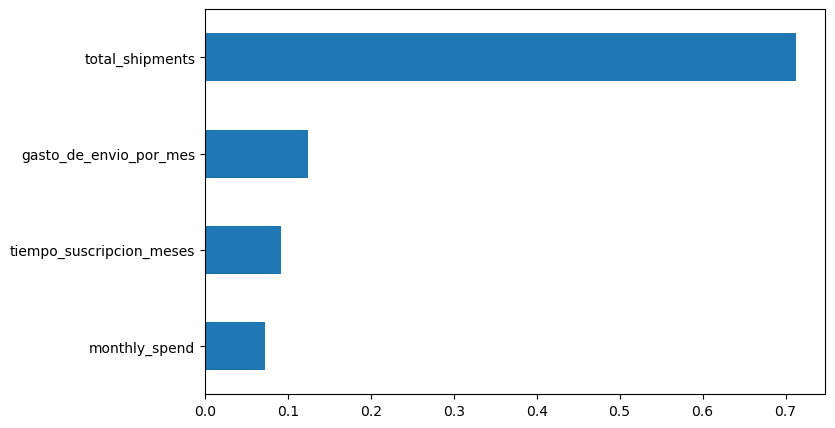

In [135]:
model1.fit(X, y) #importancia de variables

importances = pd.Series(model1.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,5))

##### Modelo 2 RandomForestClassifier

In [137]:
model2 = RandomForestClassifier(n_estimators=100,random_state=123,class_weight='balanced')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
print("RANDOM FOREST CLASSIFIER")
y_pred_cv_rf = cross_val_predict(model2, X, y, cv=skf)
print(classification_report(y, y_pred_cv_rf))

RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        83
           1       0.85      0.85      0.85        27

    accuracy                           0.93       110
   macro avg       0.90      0.90      0.90       110
weighted avg       0.93      0.93      0.93       110



<Axes: >

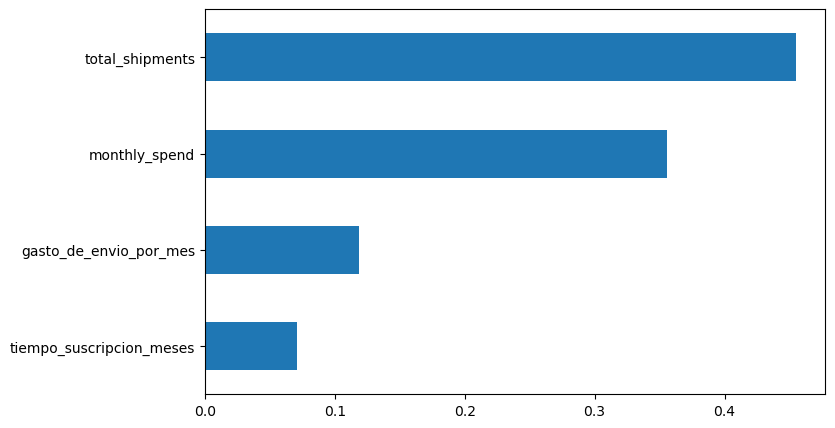

In [138]:
#Importancia de variables
model2.fit(X, y)

importances = pd.Series(model2.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,5))

##### Modelo 3 LogisticRegression

In [140]:
model3 = LogisticRegression(class_weight='balanced',max_iter=1000)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)
y_pred_cv_log = cross_val_predict(model3, X, y, cv=skf)
print("LOGISTIC REGRESSION")
print(classification_report(y, y_pred_cv_log))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.99      0.89      0.94        83
           1       0.74      0.96      0.84        27

    accuracy                           0.91       110
   macro avg       0.86      0.93      0.89       110
weighted avg       0.93      0.91      0.91       110



<Axes: >

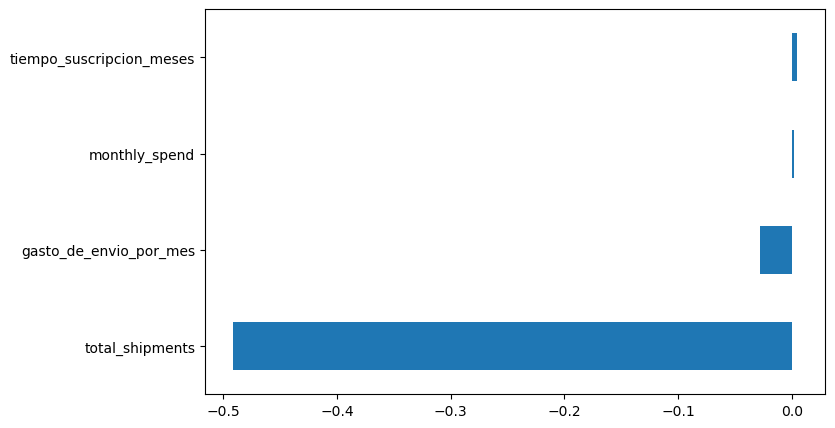

In [141]:
model3.fit(X, y) #Importancia de variables

importance = pd.Series(model3.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))

#### Resumen modelos
* El modelo Random Forest es la mejor alternativa ya que tiene una similitud entre f1-socre y recall de 0.85.
* El modelo Gradient Boosting presenta una baja comparación con Random Forest, ya que f1 score y rcall es de 0.74, por lo tanto es el segundo mejor modelo. 
* El modeo de regresión logística no presenta un balance entre recall y f1 ya que sus valore son  0.96 y 0.84, por lo tanto sería una opción descartable.